In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

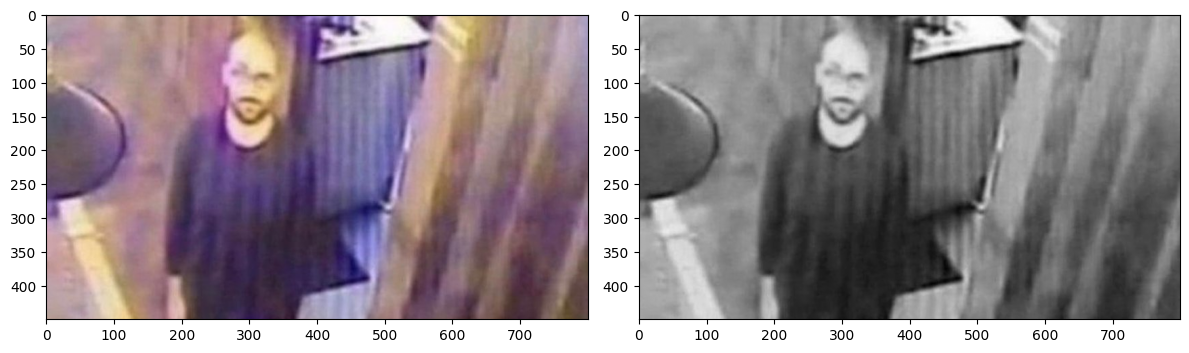

In [3]:
img_rgb = plt.imread('backup.jpg')
img_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')

plt.tight_layout()
plt.show()

plt.imread() membaca file backup.jpg dan menyimpannya sebagai array numpy dalam format RGB dengan nilai piksel 0–255. Berbeda dengan PNG yang mengembalikan float 0.0–1.0, file JPG langsung mengembalikan integer 0–255 sehingga tidak perlu dikali 255 terlebih dahulu. Kemudian cv.cvtColor() mengkonversi citra RGB ke grayscale menggunakan rumus pembobotan luminance bawaan OpenCV, menghasilkan array 2D yang hanya menyimpan informasi kecerahan tanpa informasi warna.

Kedua versi citra ditampilkan berdampingan menggunakan plt.subplot(1, 2, ...) untuk memudahkan perbandingan visual. Citra RGB menampilkan warna asli rekaman CCTV sedangkan citra grayscale menampilkan distribusi kecerahan piksel saja. Konversi ke grayscale diperlukan karena sebagian besar operasi pengolahan citra seperti filtering dan deteksi tepi bekerja pada array 2D, bukan 3D.

In [4]:
def mean_filter(citra, ukuran=3):
    h, w = citra.shape
    pad = ukuran // 2
    hasil = np.zeros((h, w), dtype=np.uint8)
    citra_pad = np.pad(citra, pad, mode='constant', constant_values=0)
    for i in range(h):
        for j in range(w):
            window = citra_pad[i:i+ukuran, j:j+ukuran]
            hasil[i, j] = int(np.mean(window))
    return hasil


def median_filter(citra, ukuran=3):
    h, w = citra.shape
    pad = ukuran // 2
    hasil = np.zeros((h, w), dtype=np.uint8)
    citra_pad = np.pad(citra, pad, mode='constant', constant_values=0)
    for i in range(h):
        for j in range(w):
            window = citra_pad[i:i+ukuran, j:j+ukuran]
            hasil[i, j] = int(np.median(window))
    return hasil


def modus_filter(citra, ukuran=3):
    h, w = citra.shape
    pad = ukuran // 2
    hasil = np.zeros((h, w), dtype=np.uint8)
    citra_pad = np.pad(citra, pad, mode='constant', constant_values=0)
    for i in range(h):
        for j in range(w):
            window = citra_pad[i:i+ukuran, j:j+ukuran].flatten()
            frek = np.zeros(256, dtype=int)
            for val in window:
                frek[val] += 1
            hasil[i, j] = np.argmax(frek)
    return hasil


def zero_padding(citra, pad):
    h, w = citra.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    hasil[pad:pad+h, pad:pad+w] = citra
    return hasil


def konvolusi(citra, kernel):
    k_h, k_w = kernel.shape
    pad = k_h // 2
    citra_pad = zero_padding(citra, pad)
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = citra_pad[i:i+k_h, j:j+k_w]
            hasil[i, j] = np.sum(region * kernel)
    return hasil


def clipping(citra):
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            val = citra[i, j]
            hasil[i, j] = 255 if val > 255 else (0 if val < 0 else int(val))
    return hasil


kernel_smoothing = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernel_sharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

Kode ini mendefinisikan semua fungsi dan kernel yang dibutuhkan untuk proses perbaikan kualitas citra. Tiga fungsi filter statistik bekerja dengan prinsip sliding window — mean_filter mengganti setiap piksel dengan rata-rata piksel sekitarnya sehingga menghasilkan efek blur merata, median_filter mengambil nilai tengah dari piksel yang diurutkan sehingga noise tereduksi tanpa merusak tepi, dan modus_filter mengambil nilai yang paling sering muncul dalam window sehingga menghasilkan efek posterisasi. Ketiga fungsi menggunakan zero padding agar ukuran output tetap sama dengan input.
Fungsi konvolusi bekerja dengan menggeser kernel di atas citra dan menjumlahkan hasil perkalian elemen per elemen antara region piksel dengan kernel. zero_padding menambahkan border hitam di sekeliling citra sebelum konvolusi agar piksel di tepi gambar tetap bisa diproses. Fungsi clipping memastikan nilai piksel hasil konvolusi tetap berada di rentang 0–255 karena operasi konvolusi bisa menghasilkan nilai negatif atau di atas 255. Kernel smoothing membagi bobot merata 1/9 ke seluruh 9 piksel dalam window 3x3 untuk menghaluskan gambar, sedangkan kernel sharpening memberi bobot besar di tengah dan negatif di sekitarnya untuk mempertegas perbedaan intensitas antar piksel.

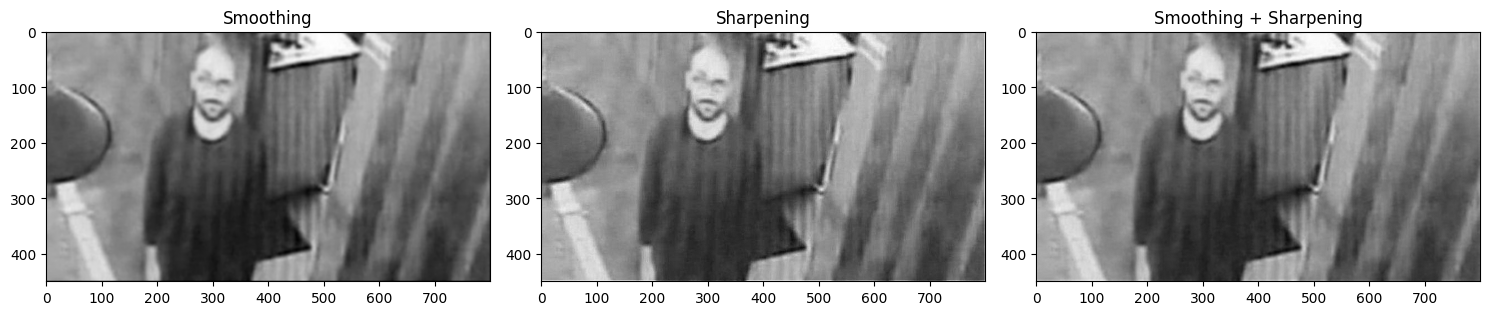

In [5]:
hasil_smooth = clipping(konvolusi(img_gray, kernel_smoothing))

hasil_sharp = clipping(konvolusi(img_gray, kernel_sharpening))

hasil_smooth_sharp = clipping(konvolusi(hasil_smooth, kernel_sharpening))

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(hasil_smooth, cmap='gray')
plt.title('Smoothing')

plt.subplot(1,3,2)
plt.imshow(hasil_sharp, cmap='gray')
plt.title('Sharpening')

plt.subplot(1,3,3)
plt.imshow(hasil_smooth_sharp, cmap='gray')
plt.title('Smoothing + Sharpening')

plt.tight_layout()
plt.show()

Smoothing berfungsi menghaluskan gambar dengan merata-ratakan nilai piksel sekitarnya. Sharpening mempertegas perbedaan intensitas antar piksel sehingga tepi dan detail objek terlihat lebih tajam, namun noise yang ada juga ikut diperkuat. Smooth + Sharp pake dua duanya, noise terlebih dahulu oleh smoothing, lalu detail yang tersisa dipertajam oleh sharpening, sehingga hasilnya lebih seimbang antara kebersihan gambar dan ketajaman detail.

Mean menghasilkan blur merata karena semua piksel dalam window diberi bobot yang sama saat dirata-ratakan. Filter Median mengambil nilai tengah dari piksel yang diurutkan sehingga noise ekstrem tidak mempengaruhi hasilnya, tepi objek lebih terjaga dibanding Mean. Filter Modus mengambil nilai yang paling sering muncul, dimana warna dominan menyebar mengisi area sekitarnya.

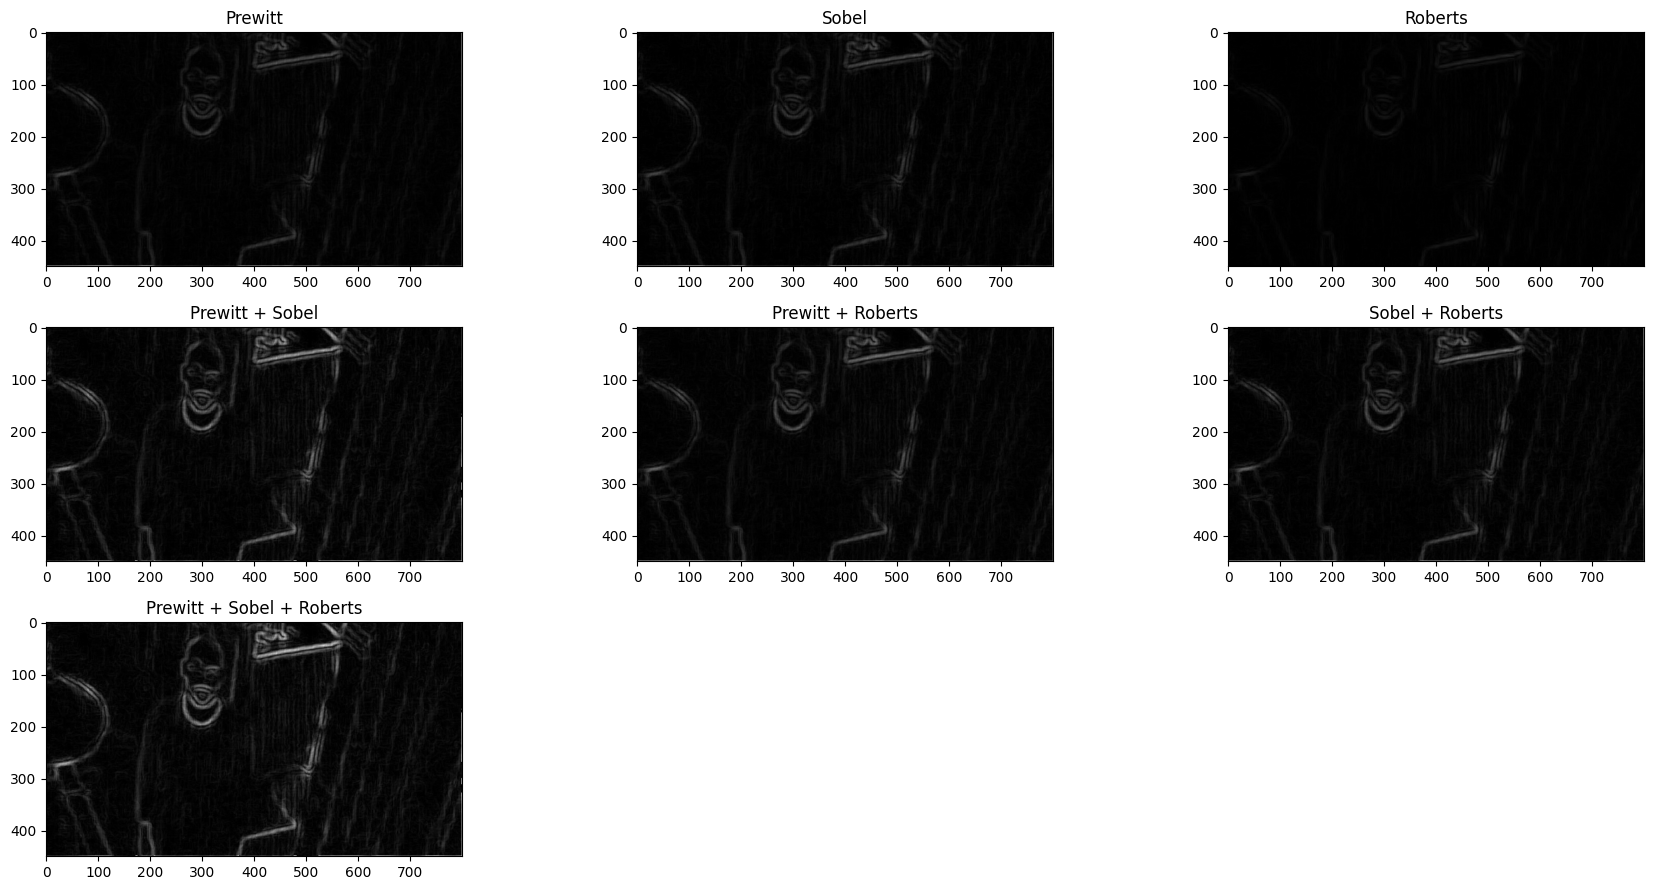

In [6]:
def deteksi_tepi(citra, kernel_x, kernel_y):
    gx = konvolusi(citra.astype(np.float64), kernel_x)
    gy = konvolusi(citra.astype(np.float64), kernel_y)
    gabung = np.abs(gx) + np.abs(gy)
    if gabung.max() > 0:
        gabung = gabung / gabung.max() * 255
    return clipping(gabung)

def normalisasi(citra):
    citra_float = citra.astype(np.float64)
    min_val = citra_float.min()
    max_val = citra_float.max()
    if max_val == min_val:
        return np.zeros(citra.shape, dtype=np.uint8)
    hasil = (citra_float - min_val) / (max_val - min_val) * 255
    return hasil.astype(np.uint8)

kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

kernel_prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])
kernel_prewitt_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

kernel_roberts_x = np.array([
    [ 1,  0],
    [ 0, -1]
])
kernel_roberts_y = np.array([
    [ 0,  1],
    [-1,  0]
])

tepi_prewitt = deteksi_tepi(img_gray, kernel_prewitt_x, kernel_prewitt_y)
tepi_sobel   = deteksi_tepi(img_gray, kernel_sobel_x, kernel_sobel_y)
tepi_roberts = deteksi_tepi(img_gray, kernel_roberts_x, kernel_roberts_y)

tepi_prewitt_sobel   = normalisasi(tepi_prewitt + tepi_sobel)
tepi_prewitt_roberts = normalisasi(tepi_prewitt + tepi_roberts)
tepi_sobel_roberts   = normalisasi(tepi_sobel + tepi_roberts)
tepi_semua           = normalisasi(tepi_prewitt + tepi_sobel + tepi_roberts)

plt.figure(figsize=(18, 9))

plt.subplot(3,3,1)
plt.imshow(tepi_prewitt, cmap='gray')
plt.title('Prewitt')

plt.subplot(3,3,2)
plt.imshow(tepi_sobel, cmap='gray')
plt.title('Sobel')

plt.subplot(3,3,3)
plt.imshow(tepi_roberts, cmap='gray')
plt.title('Roberts')

plt.subplot(3,3,4)
plt.imshow(tepi_prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')

plt.subplot(3,3,5)
plt.imshow(tepi_prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')

plt.subplot(3,3,6)
plt.imshow(tepi_sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')

plt.subplot(3,3,7)
plt.imshow(tepi_semua, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')

plt.tight_layout()
plt.show()

Fungsi deteksi_tepi bekerja dengan menghitung gradien citra ke dua arah — horizontal (gx) dan vertikal (gy) — menggunakan konvolusi dengan kernel yang berbeda. Kedua hasil gradien digabungkan dengan rumus |gx| + |gy| menggunakan nilai absolut agar tepi yang terdeteksi di kedua arah tidak saling menghilangkan. Hasilnya kemudian dinormalisasi ke rentang 0–255 agar bisa divisualisasikan. Tiga kernel deteksi tepi didefinisikan dengan karakteristik berbeda — Sobel memberi bobot ±2 di baris/kolom tengah sehingga lebih tahan noise, Prewitt menggunakan bobot ±1 yang seragam sehingga lebih sensitif tapi konsisten, dan Roberts menggunakan kernel diagonal 2x2 yang sangat kecil sehingat paling cepat namun paling rentan noise.
Kombinasi operator dilakukan dengan menjumlahkan hasil deteksi tepi masing-masing operator lalu dinormalisasi menggunakan fungsi normalisasi. Prewitt + Sobel menghasilkan tepi yang lebih tebal karena kedua operator sama-sama mendeteksi arah horizontal dan vertikal sehingga saling memperkuat. Prewitt + Roberts dan Sobel + Roberts menambahkan informasi tepi diagonal dari Roberts sehingga kontur yang miring lebih terlihat. Kombinasi ketiganya Prewitt + Sobel + Roberts menghasilkan deteksi tepi paling lengkap karena menggabungkan kekuatan ketiga operator, namun juga paling rentan terhadap noise karena semua tepi termasuk noise ikut terjumlahkan.

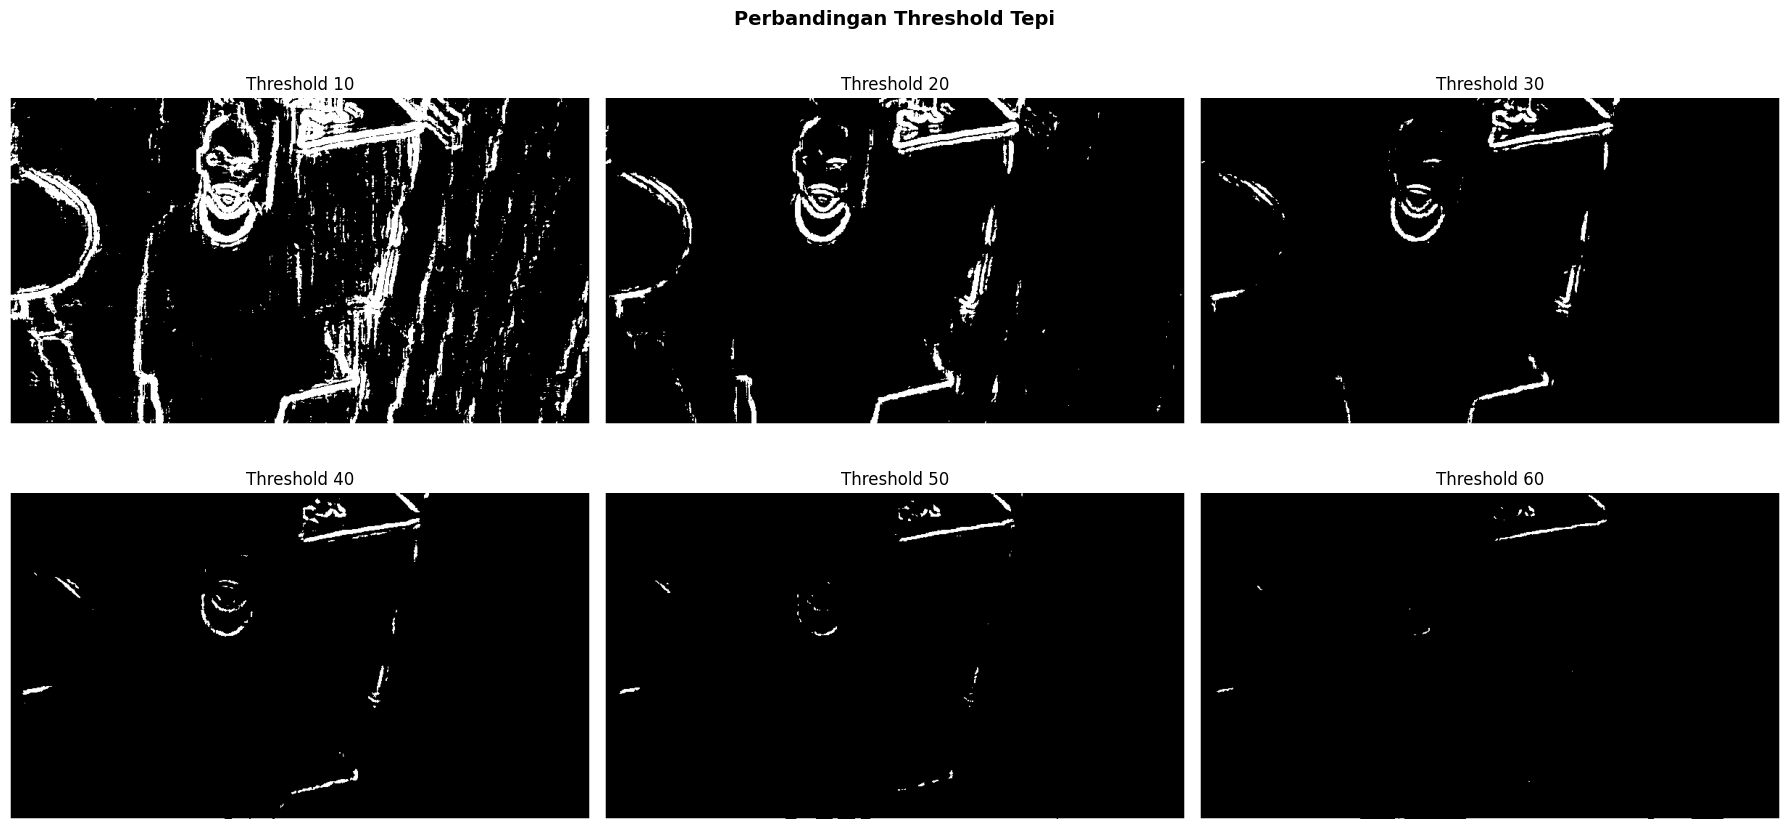

In [7]:
def threshold_tepi(citra, nilai):
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if citra[i, j] >= nilai:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0
    return hasil

thresh_10 = threshold_tepi(tepi_sobel, 10)
thresh_20 = threshold_tepi(tepi_sobel, 20)
thresh_30 = threshold_tepi(tepi_sobel, 30)
thresh_40 = threshold_tepi(tepi_sobel, 40)
thresh_50 = threshold_tepi(tepi_sobel, 50)
thresh_60 = threshold_tepi(tepi_sobel, 60)

plt.figure(figsize=(18, 9))

plt.subplot(2, 3, 1)
plt.imshow(thresh_10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(thresh_20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(thresh_30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(thresh_40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(thresh_50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(thresh_60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')

plt.suptitle('Perbandingan Threshold Tepi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Fungsi threshold_tepi mengubah hasil deteksi tepi menjadi citra biner — piksel yang nilainya lebih besar atau sama dengan nilai threshold diset menjadi 255 (putih) dan sisanya menjadi 0 (hitam). Threshold diterapkan pada hasil tepi_sobel dengan 6 nilai berbeda yaitu 10, 20, 30, 40, 50, dan 60 untuk membandingkan pengaruh nilai threshold terhadap informasi tepi yang tertampil.
Threshold rendah seperti 10 dan 20 menghasilkan banyak piksel putih karena hampir semua gradien ikut terdeteksi termasuk noise dan tekstur halus yang tidak penting, sehingga gambar terlihat ramai dan sulit dibaca. Sebaliknya threshold tinggi seperti 50 dan 60 hanya menyisakan tepi dengan perubahan intensitas yang sangat kuat sehingga banyak detail penting yang hilang dan gambar terlihat sangat jarang. Nilai threshold paling bagus untuk kasus citra CCTV ini adalah 30, karena pada nilai tersebut tepi utama seperti kontur wajah, bahu, dan objek di sekitar orang masih terlihat jelas tanpa terlalu banyak noise yang mengganggu — keseimbangan antara detail yang dipertahankan dan noise yang dihilangkan paling optimal di nilai ini.

In [29]:
# Cek nilai RGB di beberapa titik
print('area kayu:', img_rgb[50, 200])    # koordinat area kayu
print('area baju:', img_rgb[300, 250])   # koordinat area baju
print('area kulit:', img_rgb[100, 280])  # koordinat area wajah

area kayu: [176 137 138]
area baju: [66 45 88]
area kulit: [244 202 226]


Fungsi print ini digunakan untuk mengecek nilai RGB di beberapa titik koordinat yang mewakili area berbeda pada citra, area kayu sebagai background, area baju orang, dan area kulit wajah. Hasilnya digunakan sebagai acuan untuk menentukan kondisi masking yang tepat, karena setiap area memiliki karakteristik nilai R, G, B yang berbeda. Dari hasil print diketahui bahwa kayu memiliki nilai R sedang dengan G dan B yang mirip, baju memiliki nilai B lebih tinggi dari R karena warnanya ungu gelap, dan kulit memiliki semua channel tinggi dengan R paling dominan. Informasi ini menjadi dasar penentuan kondisi threshold RGB pada proses masking selanjutnya.

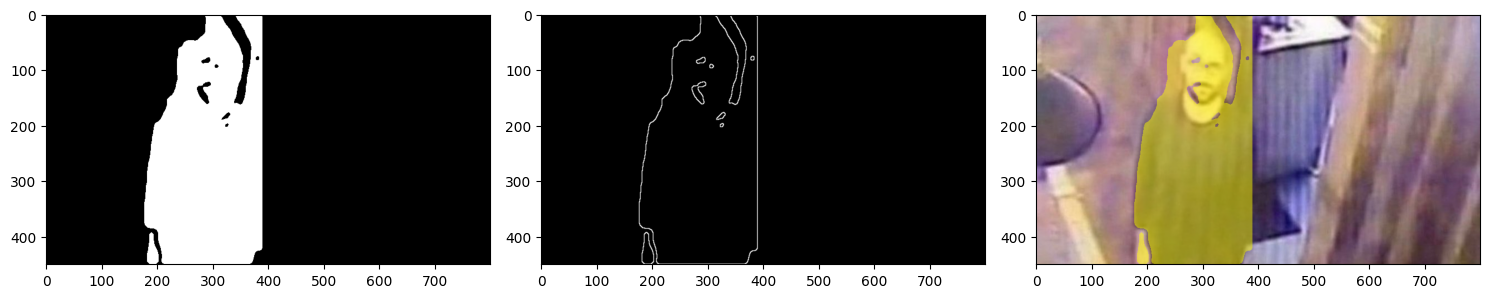

In [34]:
h, w = img_gray.shape
mask_orang = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(175, 390):
        R = int(img_rgb[i, j, 0])
        G = int(img_rgb[i, j, 1])
        B = int(img_rgb[i, j, 2])
        if 120 < R < 200 and abs(int(G) - int(B)) < 30 and R > G:
            mask_orang[i, j] = 0    # kayu → hitam
        else:
            mask_orang[i, j] = 255  # orang → putih

mask_orang = median_filter(mask_orang, 9)

# Deteksi tepi dari mask
tepi_siluet = deteksi_tepi(mask_orang, kernel_sobel_x, kernel_sobel_y)

# Overlay kuning transparan (alpha blending)
alpha = 0.5  # tingkat transparansi, 0=full asli, 1=full kuning

if img_rgb.max() <= 1.0:
    highlight = (img_rgb * 255).astype(np.uint8)
else:
    highlight = img_rgb.copy()

for i in range(h):
    for j in range(w):
        if mask_orang[i, j] == 255:
            highlight[i, j, 0] = int(highlight[i, j, 0] * (1 - alpha) + 255 * alpha)
            highlight[i, j, 1] = int(highlight[i, j, 1] * (1 - alpha) + 255 * alpha)
            highlight[i, j, 2] = int(highlight[i, j, 2] * (1 - alpha) + 0 * alpha)
            
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_orang, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(tepi_siluet, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(highlight)

plt.tight_layout()
plt.show()

Proses masking dimulai dengan membuat canvas kosong berukuran sama dengan citra grayscale menggunakan np.zeros. Loop hanya dilakukan pada kolom 175 sampai 390 karena berdasarkan pengukuran koordinat menggunakan aplikasi Paint, area orang berada di rentang kolom tersebut, sehingga piksel di luar rentang ini otomatis tetap bernilai 0 (hitam) dan objek lain seperti tong hitam di kiri dan mesin di kanan tidak ikut termasking. Kondisi masking menggunakan hasil analisis nilai RGB yang sudah dicek sebelumnya, dimana piksel dengan nilai 120 < R < 200 dan selisih G dengan B kurang dari 30 dan R lebih besar dari G diklasifikasikan sebagai kayu karena kayu memiliki R sedang dengan G dan B yang mirip. Piksel yang tidak memenuhi kondisi tersebut dianggap sebagai orang (kulit atau baju) dan diset menjadi 255 (putih). Setelah masking, median_filter dengan ukuran 9 diterapkan untuk merapikan mask dari titik-titik kecil yang salah terdeteksi.
Dari mask yang sudah rapi, deteksi tepi diterapkan menggunakan kernel Sobel untuk mendapatkan garis kontur siluet orang. Untuk overlay kuning, digunakan teknik alpha blending dengan nilai alpha 0.5, dimana nilai ini menentukan seberapa kuat warna kuning bercampur dengan warna asli gambar, dengan 0 berarti warna asli penuh dan 1 berarti kuning penuh. Setiap piksel yang masuk area mask dihitung ulang nilainya dengan rumus nilai_asli * (1 - alpha) + nilai_kuning * alpha untuk ketiga channel R, G, B secara terpisah, dimana channel R dan G diberi nilai 255 dan channel B diberi nilai 0 untuk menghasilkan warna kuning. Hasilnya ditampilkan tiga gambar berdampingan yaitu mask siluet, deteksi tepi siluet, dan highlight kuning transparan di atas gambar asli.

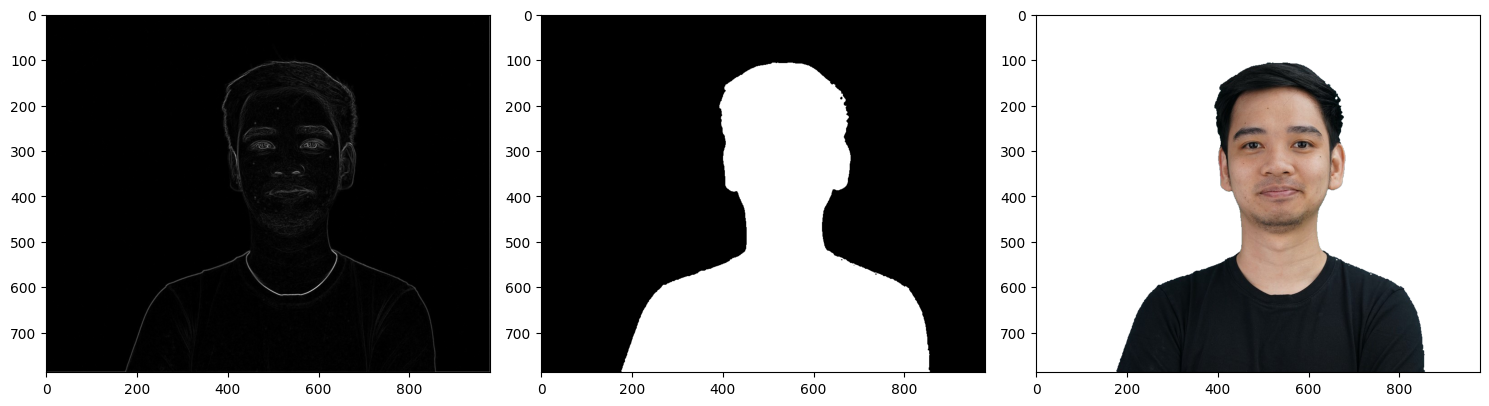

In [33]:
david_rgb = plt.imread('david.jpg')
david_gray = cv.cvtColor(david_rgb, cv.COLOR_RGB2GRAY)

tepi_david = deteksi_tepi(david_gray, kernel_sobel_x, kernel_sobel_y)

h, w = david_gray.shape
mukaDavid = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        Red   = int(david_rgb[i, j, 0])
        Green = int(david_rgb[i, j, 1])
        Blue  = int(david_rgb[i, j, 2])
        if Green > Red + 20 and Blue > Red: # ini buat kondisi kalau warna toska itu dominan hijau dan biru
            mukaDavid[i, j] = 0    
        else:
            mukaDavid[i, j] = 255  

mukaDavid = median_filter(mukaDavid)

hasil_david = david_rgb.copy()
for i in range(h):
    for j in range(w):
        if mukaDavid[i, j] == 0:
            hasil_david[i, j, 0] = 255
            hasil_david[i, j, 1] = 255
            hasil_david[i, j, 2] = 255

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(tepi_david, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(mukaDavid, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(hasil_david)
plt.tight_layout()
plt.show()

Citra david.jpg dibaca menggunakan plt.imread yang mengembalikan format RGB, lalu dikonversi ke grayscale menggunakan cv.cvtColor untuk keperluan deteksi tepi. Deteksi tepi dilakukan menggunakan kernel Sobel yang menghasilkan garis kontur wajah, rambut, dan pakaian dengan cukup jelas karena citra pas foto memiliki pencahayaan yang lebih baik dibanding citra CCTV sehingga perbedaan intensitas antar area lebih tajam.
Proses masking background dilakukan dengan memeriksa nilai RGB setiap piksel di seluruh gambar. Kondisi Green > Red + 20 dan Blue > Red digunakan untuk mendeteksi piksel berwarna toska karena warna toska memiliki karakteristik channel hijau dan biru yang dominan mengalahkan channel merah, dimana selisih Green terhadap Red minimal 20 digunakan agar tidak terlalu sensitif terhadap piksel yang kebetulan sedikit kehijauan. Piksel yang memenuhi kondisi toska diset menjadi 0 (hitam) sebagai background, sedangkan sisanya diset menjadi 255 (putih) sebagai foreground. Setelah mask terbentuk, median_filter diterapkan untuk merapikan titik-titik kecil yang salah terdeteksi tanpa menggunakan operasi morfologi. Terakhir setiap piksel yang masknya bernilai 0 pada hasil_david diganti dengan nilai 255 di ketiga channel R, G, dan B sehingga background menjadi putih bersih sementara area foreground tetap mempertahankan warna aslinya..